In [27]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pickle
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader, ConcatDataset, WeightedRandomSampler
import math
import scipy.special
import random as rd
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from torchvision.models import VGG16_Weights
from typing import Tuple
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgp_utils import *
from python_scripts.preprocessing import *
from python_scripts.plotting import *
from python_scripts import plotting
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


### Load cnn and CIFAR10 data

In [2]:
# Define transforms for CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]) # imageNet stats by rgb channel

# Load full training set (50,000 samples)
full_train_dataset = datasets.CIFAR10(root="C:/Users/ejeme/Documents/python_repos/CIFAR/cifar_data", train=True, transform=transform, download=True)
# Load official test set (10,000 samples)
official_test_dataset = datasets.CIFAR10(root="C:/Users/ejeme/Documents/python_repos/CIFAR/cifar_data", train=False, transform=transform, download=True)

# airplance = 1, not airplane = 0
binarize_labels(full_train_dataset)
binarize_labels(official_test_dataset)

In [3]:
# Combine both datasets
combined_dataset = ConcatDataset([full_train_dataset, official_test_dataset])
# Total combined length
total_length = len(combined_dataset)
# Shuffle and split indices
indices = list(range(total_length))
rd.shuffle(indices)
# Split into train (for cnn training) and test (which will be training+test sets for Selective Prediction module)
train_indices = indices[:20000]
test_indices = indices[20000:]
# Create subsets
new_train_dataset = Subset(combined_dataset, train_indices)
new_test_dataset = Subset(combined_dataset, test_indices)
# get their associated labels from combined_dataset
train_labels = get_subset_labels(new_train_dataset, combined_dataset)
test_labels = get_subset_labels(new_test_dataset, combined_dataset)

# Create test dataloader (which will be training+test sets for Selective Prediction module)
test_loader = DataLoader(new_test_dataset, batch_size=6, shuffle=False)

# Create balanced samplers for training and validation of cnn
train_sampler = get_balanced_sampler(train_labels)
val_sampler = get_balanced_sampler(test_labels)
# Create DataLoaders using balanced samplers
train_loader = DataLoader(new_train_dataset, batch_size=6, sampler=train_sampler)
val_loader = DataLoader(new_test_dataset, batch_size=6, sampler=val_sampler)

In [4]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SmallCNN(nn.Module):
    def __init__(self, p=0.2):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 20, 4, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p)
        self.conv2 = nn.Conv2d(20, 32, 4, padding=1)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.dropout = nn.Dropout(p)            # train-time and MC-dropout layer
        self.fc1 = nn.Linear(32 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(self.dropout(F.relu(self.conv2(x))))
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))   # dropout used here
        x = self.fc2(x)
        return x


# Initialize the model
cnn = SmallCNN().to(device)

In [5]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load trained cnn
cnn = SmallCNN().to(device)
checkpoint = torch.load("C:/Users/ejeme/Documents/python_repos/selective-classification/models_weights/cnn_cifar_binary_MCD_epoch9.pth", map_location=torch.device('cpu'))
cnn.load_state_dict(checkpoint)

<All keys matched successfully>

In [34]:
i = iter(test_loader)

In [54]:
batch = next(i)
images, labels = batch
images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

logits = cnn(images)

print(labels)
print(F.softmax(logits, dim=1))

tensor([0, 0, 0, 0, 0, 1], device='cuda:0')
tensor([[0.1575, 0.8425],
        [0.6021, 0.3979],
        [0.9986, 0.0014],
        [0.4922, 0.5078],
        [0.9981, 0.0019],
        [0.6285, 0.3715]], device='cuda:0', grad_fn=<SoftmaxBackward0>)


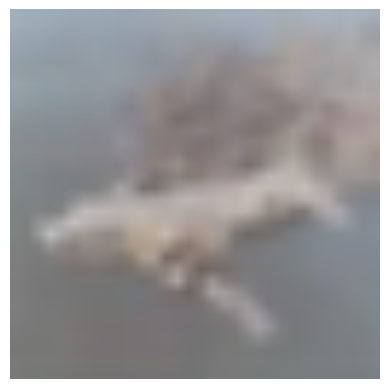

In [55]:
plotting.show_cifar10(images[5])

In [6]:
sgp_df_SR = pickle.load(open('sgp_set_cnn','rb')) 
print(sgp_df_SR.shape)
print('1s prop = ', sgp_df_SR.y_true.sum()/sgp_df_SR.shape[0])
sgp_df_SR.head() 

(40000, 3)
1s prop =  0.1012


,y_true,y_pred,kappa
0,0.0,0.0,0.968736
1,0.0,1.0,0.870544
2,0.0,0.0,0.882295
3,0.0,0.0,0.768718
4,0.0,1.0,0.739913


In [7]:
train_set_SR = sgp_df_SR.iloc[:3*int(len(sgp_df_SR)/4)]
train_set_SR = train_set_SR.sort_values('kappa', ascending=True).reset_index(drop=True).copy()
test_set_SR = sgp_df_SR.iloc[3*int(len(sgp_df_SR)/4):]

In [8]:
delta = 0.005

In [9]:
color_map = {'standard': "#d51414",
             'FP': "#e5be12",
             'FN': "#27e21d",
             'FPR': "#403535",
             'FNR': "#1d3ae2",
             'SE': "#d51de2",
             'SP': "#16CEE2",
             'PPV': "#676767"}

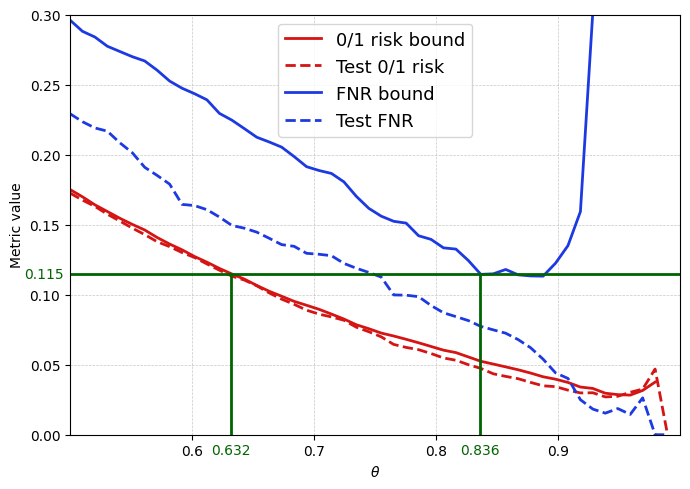

In [56]:
label_map = {'standard': '0/1 risk',
             'FNR': 'FNR'}
level =0.115

def _interpolated_crossing(t, b, level=level):
    """
    Return theta where b crosses down through `level`, via linear interpolation.
    Handles:
      - exact hits (b == level),
      - sign changes (> level to <= level),
      - no-crossing (returns closest point to level).
    """
    t = np.asarray(t, dtype=float)
    b = np.asarray(b, dtype=float)
    d = b - level

    # Exact hits first
    hit_idx = np.where(d == 0)[0]
    if hit_idx.size > 0:
        return float(t[hit_idx[0]])

    # Indices where signbit changes (crossing level)
    sign_changes = np.where(np.diff(np.signbit(d)))[0]
    for i in sign_changes:
        # ensure it's a downward crossing (b[i] > level, b[i+1] < level)
        if b[i] > level and b[i+1] < level:
            t0, t1 = t[i], t[i+1]
            b0, b1 = b[i], b[i+1]
            # linear interpolation fraction where b hits 'level'
            frac = (b0 - level) / (b0 - b1) if b0 != b1 else 0.0
            return float(t0 + frac * (t1 - t0))

    # If we got here, no downward crossing — snap to closest value
    return float(t[np.argmin(np.abs(d))])

def plot_metrics_on_ax(ax, metrics_subset, label_getter):
    last_thetas = None
    crossings = {}  # metric -> theta at level (interpolated)

    for metric in metrics_subset:
        color = color_map[metric]
        thetas, bounds = bound_evo_w_theta(metric, train_set_SR, delta, steps=50)
        last_thetas = thetas

        thetas_arr = np.asarray(thetas, dtype=float)
        bounds_arr = np.asarray(bounds, dtype=float)

        # Interpolated (robust) crossing
        crossings[metric] = _interpolated_crossing(thetas_arr, bounds_arr, level=level)

        # Train bound curve
        ax.plot(thetas_arr, bounds_arr, color=color,
                label=label_getter(metric) + ' bound', linewidth=2)

        # Test empirical metric
        emp_metrics, test_coverages = [], []
        for theta in thetas_arr:
            selected_set = test_set_SR.loc[test_set_SR.kappa >= theta].copy()
            test_coverages.append(selected_set.shape[0] / test_set_SR.shape[0])
            try:
                emp_metrics.append(emp_metric(selected_set, metric=metric))
            except ValueError:
                emp_metrics.append(np.nan)

        ax.plot(thetas_arr, emp_metrics, linestyle='--', color=color,
                label='Test ' + label_getter(metric), linewidth=2)

    # Formatting
    ax.set_xlim(float(np.min(last_thetas)), float(np.max(last_thetas)))
    ax.set_xlabel(r'$\theta$')
    ax.set_ylim(0, 0.3)
    ax.set_ylabel('Metric value')
    ax.legend(fontsize=13, loc="upper center")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Green guide style: match bound thickness
    green_style = dict(color='darkgreen', linestyle='-', linewidth=2)

    # Horizontal green line at y=level
    ax.axhline(y=level, **green_style)

    # Label "level" in green just left of the y-axis at the line
    ax.text(-0.01, level, str(level), color='darkgreen',
            transform=ax.get_yaxis_transform(), va='center', ha='right')

    # Vertical green lines at each metric's crossing, from x-axis up to level
    ymin, ymax = ax.get_ylim()
    for m in ('standard', 'FNR'):
        if m in crossings and crossings[m] is not None:
            xval = crossings[m]
            ax.vlines(xval, ymin=ymin, ymax=level, **green_style)

            # Add green text label of xval at bottom (just below x-axis ticks)
            ax.text(xval, ymin - 0.02*(ymax - ymin),
                    f"{xval:.3f}", color='darkgreen',
                    ha='center', va='top')


# One simple plot (no subplots): only 'standard' and 'FNR'
fig, ax = plt.subplots(figsize=(7, 5))
metrics_to_plot = ['standard', 'FNR']
plot_metrics_on_ax(ax, metrics_to_plot, lambda m: label_map[m])
plt.tight_layout()
plt.show()